In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
# LLM 선언 - AzureOpenAI 로 활용해도 됨

from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o-mini") 
small_llm = ChatOpenAI(model="gpt-4o-mini")

In [3]:
from langchain_core.tools import tool


@tool
def add(a: int, b:int) -> int:
    """
        숫자 a 와 b를 더합니다    
    """
    return a + b


@tool
def multiply(a: int, b: int) -> int:
    """
        숫자 a 와 b를 곱합니다    
    """
    return a * b


In [4]:
from langchain_community.tools import DuckDuckGoSearchRun

search_tool = DuckDuckGoSearchRun()


In [5]:
# Gmail 도구를 추가
from langchain_google_community.gmail.utils import (
    build_resource_service,
    get_gmail_credentials,
)
from langchain_google_community import GmailToolkit

# 이 방식을 추천 => 변수를 넘기면서 credential, token json 파일을 관리할 수 있다
credentials = get_gmail_credentials(
    token_file="./google/gmail_token.json",   # credentials를 기반으로 메일 권한을 가지고 토큰을 생성해서 파일에 저장
    scopes=["https://mail.google.com/"],
    client_sercret_file="./google/gmail_credentials.json",   #client_sercret_file 오타가 있는 파라미터로...
)
api_resource = build_resource_service(credentials=credentials)
gmail_toolkit = GmailToolkit(api_resource=api_resource)

# 한번 인증을 받으면, 다시 실행해도 넘어간다. 
# gmail_toolkit에서 도구를 받아올 수 있는 상태. 
gmail_tool_list = gmail_toolkit.get_tools()
# toolkit = GmailToolkit()   # 이걸 활용하고자 한다면 -> 파일 이름 명시 불가. credential.json이라고만 해줘야 함 (위 코드 참고)

C:\Users\KE126\AppData\Local\Temp\ipykernel_26188\1902096436.py:9: DeprecationWarning: get_gmail_credentials is deprecated and will be removed in a future version.Use get_google_credentials instead.
  credentials = get_gmail_credentials(
C:\Users\KE126\AppData\Local\Temp\ipykernel_26188\1902096436.py:14: DeprecationWarning: build_resource_service is deprecated and will be removed in a future version.Use build_gmail_service instead.
  api_resource = build_resource_service(credentials=credentials)


In [6]:
gmail_tool_list
# %pip freeze > requirements.txt

[GmailCreateDraft(api_resource=<googleapiclient.discovery.Resource object at 0x000001780F681BE0>),
 GmailSendMessage(api_resource=<googleapiclient.discovery.Resource object at 0x000001780F681BE0>),
 GmailSearch(api_resource=<googleapiclient.discovery.Resource object at 0x000001780F681BE0>),
 GmailGetMessage(api_resource=<googleapiclient.discovery.Resource object at 0x000001780F681BE0>),
 GmailGetThread(api_resource=<googleapiclient.discovery.Resource object at 0x000001780F681BE0>)]

In [7]:
%pip install -qU  langchain-community arxiv

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
# %pip install langchain --upgrade

In [9]:
# 아카이브 논문 툴
# from langchain.agents import load_tools  # ImportError: cannot import name 'load_tools' from 'langchain.agents'  에러
from langchain_community.agent_toolkits.load_tools import load_tools
from langchain_openai import ChatOpenAI

# llm = ChatOpenAI(temperature=0.0)
loaded_tool_list = load_tools(
    ["arxiv"],
)


#### create_retriever_tool

In [22]:
from langchain_openai import OpenAIEmbeddings
from langchain_chroma import Chroma
from langchain_core.tools.retriever import create_retriever_tool  


embedding_function = OpenAIEmbeddings(model="text-embedding-3-large")

vector_store = Chroma(
    embedding_function=embedding_function,
    collection_name='real_estate_tax',
    persist_directory='./real_estate_tax_collection'  # 로컬에 남아있음
)

retriever = vector_store.as_retriever(search_kwargs={"k": 3})  # 검색할 때, 가장 유사한 3개의 문서를 가져오도록 설정

retriever_tool = create_retriever_tool(
    retriever=retriever,
    name='real_estate_tax_retriever',
    description='Contains information about real estate tax'
)

#### langgraph에서 ToolNode

In [10]:
from langgraph.prebuilt import ToolNode

# tool_list = [add, multiply, search_tool, gmail_tool_list]
tool_list = [add, multiply, search_tool, retriever_tool] + gmail_tool_list  + loaded_tool_list

llm_with_tools = small_llm.bind_tools(tool_list)  # LLM 바인딩 
tool_node = ToolNode(tool_list)   # 랭그래프 바인딩 

In [11]:
# state 선언 : messages의 경우, langgraph가 내장으로 제공하는 state가 있다
from langgraph.graph import MessagesState, StateGraph

graph_builder = StateGraph(MessagesState)



In [12]:
# 1. 에이전트 노드를 생성 <- LLM을 호출하는, llm_with_tools는 messages를 넣어서 invoke만 하는 용도로...

# HumanMessage -> messages 에 추가
# AiMessage -> messages 에 추가
# ToolMessage -> messages 에 추가
# 추가할 때, append 할 필요는 아니고, add_messages 함수를 활용해서 추가할 수 있다.

def agent(state: MessagesState):
    messages = state['messages']
    response = llm_with_tools.invoke(messages)   # ai_messages와 동일
    
    return {'messages':[response]}

In [14]:
graph_builder.add_node('agent', agent)
graph_builder.add_node('tools', tool_node)
# should_continue -> 분간하는 노드는 추가 안함

In [15]:
# 엣지 추가
from langgraph.graph import START, END
from langgraph.prebuilt import tools_condition  # tools condition -> 실행하면 should continue 노드가 불필요해진다

graph_builder.add_edge(START, 'agent')
graph_builder.add_conditional_edges(
    'agent',
    tools_condition 
)

graph_builder.add_edge('tools', 'agent')

In [16]:
graph = graph_builder.compile()

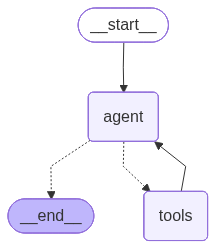

In [17]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))  


In [23]:
# 호출
from langchain_core.messages import HumanMessage

# query = 'What currency is in Billy Giles\'birthplace?'   # 이 질문을 고른 이유 : 논문에 나온 쿼리임 (Adaptive Approch)
# query = 'What currency is in Billy Giles\'birthplace? Find the currency and email it to 4yrpbusiness@gmail.com'  # gmail took을 활용하기 위한 쿼리


query = 'Attention Is All You Need라는논문을 요약해서 4yrpbusiness@gmail.com으로 메일을 보내주세요'  # small_llm은 초안만 작성하고 보내지는 않았다면 -> LLM을 큰걸로 쓰거나, 프롬프트를 수정하자 (큰 LLM일수록 고급스러운 작업을 한다.)
    # 채팅 히스토리 관리가 안되어있기 때문에, 두번째 물어봐도 작성한 초안을 전송할 수 없다 -> 에이전트와 다이나믹하게 소통(히스토리를 관리)해야 함 (3.5)


# query = '집이 15억일 때 종합부동산세를 계산해줄 수 있나요?'   # create_retriever_tools
for chunk in graph.stream({'messages': [HumanMessage(query)]}, stream_mode='values'): # full state를 볼 수 있음
    chunk['messages'][-1].pretty_print()


================================ Human Message =================================

집이 15억일 때 종합부동산세를 계산해줄 수 있나요?
================================== Ai Message ==================================

종합부동산세는 주택이 보유한 가액에 따라 다르게 부과됩니다. 2023년 기준으로 주택에 대한 종합부동산세는 기본 세율이 다르며, 주택 수와 공시지가에 따라 차이가 있을 수 있습니다.

1. **주택 보유 수**: 1주택인지 2주택인지에 따라 다름
2. **공시지가**: 주택의 공시지가에 따라서도 세금이 달라짐
3. **세율**: 기본 세율은 0.5%에서 2%까지 적용됨

가정하에 15억 원의 주택을 1주택으로 보유하고 있다고 가정하겠습니다.

2023년 기준으로는 기본적인 종합부동산세 세율은 다음과 같습니다:

- 공정 시장 가액이 6억 원 이하: 0.5%
- 6억 원 초과 12억 원 이하: 0.7%
- 12억 원 초과 50억 원 이하: 1.0%
- 50억 원 초과: 2.0%

15억 원 주택의 경우, 세금 계산은 다음과 같이 진행됩니다:

1. 6억 원까지: 6억 × 0.5% = 30만 원
2. 6억 원 초과 12억 원까지: (12억 - 6억) × 0.7% = 42만 원
3. 12억 원 초과 15억 원까지: (15억 - 12억) × 1.0% = 30만 원

따라서 총 세금은:

30만 원 + 42만 원 + 30만 원 = 102만 원

이것은 대략적인 계산이며, 실제 세금은 개인의 상황에 따라 달라질 수 있습니다. 정확한 세금 계산을 원하시면 세무사와 상담하시기 바랍니다.


In [19]:
# 이걸 워크플로우로 작성했다면, 
# 복잡한 츨로우가 나올 수도 있음.
# 에이전트를 구축하면, 단순 검색 도구만 줘도 생성할 워크플로우들의 기능을 구현할 수  있다.

#### gmail toolkit 도구 활용

In [20]:
%pip install arxiv

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
